# 01 – Exploratory Data Analysis
Quick exploration of the 5,000-row freMTPL sample.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.insert(0, "../src")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
%matplotlib inline


In [2]:
from glm_pricing.data import load_freq
df = load_freq("../data/sample/freMTPL_sample.csv")
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nHead:\n", df.head())


Shape: (5000, 13)

Dtypes:
 IDpol                   str
ClaimNb               int64
Exposure            float64
Area                    str
VehPower              int64
VehAge                int64
DrivAge               int64
BonusMalus            int64
VehBrand                str
VehGas                  str
Density               int64
Region                  str
ClaimAmountTotal    float64
dtype: object

Head:
   IDpol  ClaimNb  Exposure Area  VehPower  VehAge  DrivAge  BonusMalus  \
0   501        1      0.84    C         6       2       41          50   
1   527        1      0.84    C        10       7       43          50   
2   719        1      0.90    B        10       0       45          50   
3   933        1      0.72    C         6       0       75          50   
4  1182        1      0.70    C         6       0       47          50   

  VehBrand     VehGas  Density Region  ClaimAmountTotal  
0      B12   'Diesel'      343    R72               0.0  
1      B12  'Regular'    

In [3]:
print("Summary stats:")
df.describe(include="all")


Summary stats:


,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region,ClaimAmountTotal
count,5000,5000.000000,5000.000000,5000,5000.000000,5000.0000,5000.000000,5000.000000,5000,5000,5000.000000,5000,5000.000000
unique,5000,NaN,NaN,6,NaN,NaN,NaN,NaN,11,2,NaN,22,NaN
top,501,NaN,NaN,C,NaN,NaN,NaN,NaN,B12,'Regular',NaN,R24,NaN
freq,1,NaN,NaN,1421,NaN,NaN,NaN,NaN,1236,2614,NaN,1169,NaN
mean,NaN,0.052800,0.524512,NaN,6.477000,7.0302,45.600200,59.640400,NaN,NaN,1784.403800,NaN,56.691036
std,NaN,0.234996,0.365924,NaN,2.045265,5.6489,14.368244,15.600262,NaN,NaN,3930.056111,NaN,566.121191
min,NaN,0.000000,0.002732,NaN,4.000000,0.0000,18.000000,50.000000,NaN,NaN,3.000000,NaN,0.000000
25%,NaN,0.000000,0.160000,NaN,5.000000,2.0000,34.000000,50.000000,NaN,NaN,91.750000,NaN,0.000000
50%,NaN,0.000000,0.490000,NaN,6.000000,6.0000,44.000000,50.000000,NaN,NaN,384.000000,NaN,0.000000
75%,NaN,0.000000,0.990000,NaN,7.000000,11.0000,55.000000,64.000000,NaN,NaN,1600.250000,NaN,0.000000


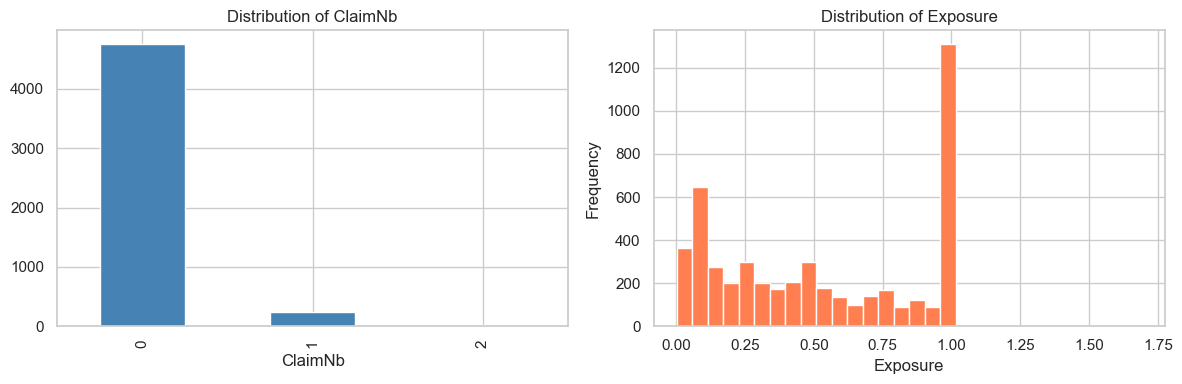

Saved plot


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["ClaimNb"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of ClaimNb")
axes[0].set_xlabel("ClaimNb")
df["Exposure"].plot(kind="hist", bins=30, ax=axes[1], color="coral", edgecolor="white")
axes[1].set_title("Distribution of Exposure")
axes[1].set_xlabel("Exposure")
plt.tight_layout()
plt.savefig("../data/sample/eda_claimnb_exposure.png", dpi=80)
plt.show()
print("Saved plot")


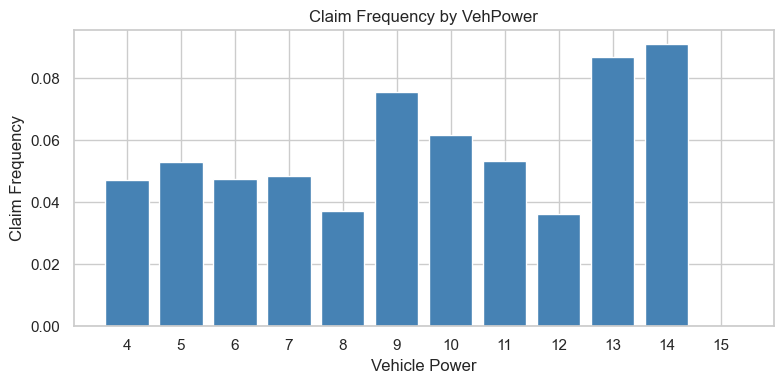

In [5]:
# Claim frequency by VehPower
freq_by_power = (
    df.groupby("VehPower")
    .agg(claim_freq=("ClaimNb", lambda x: (x.astype(float) > 0).mean()))
    .reset_index()
)
plt.figure(figsize=(8, 4))
plt.bar(freq_by_power["VehPower"].astype(str), freq_by_power["claim_freq"], color="steelblue")
plt.title("Claim Frequency by VehPower")
plt.xlabel("Vehicle Power")
plt.ylabel("Claim Frequency")
plt.tight_layout()
plt.savefig("../data/sample/eda_freq_by_power.png", dpi=80)
plt.show()


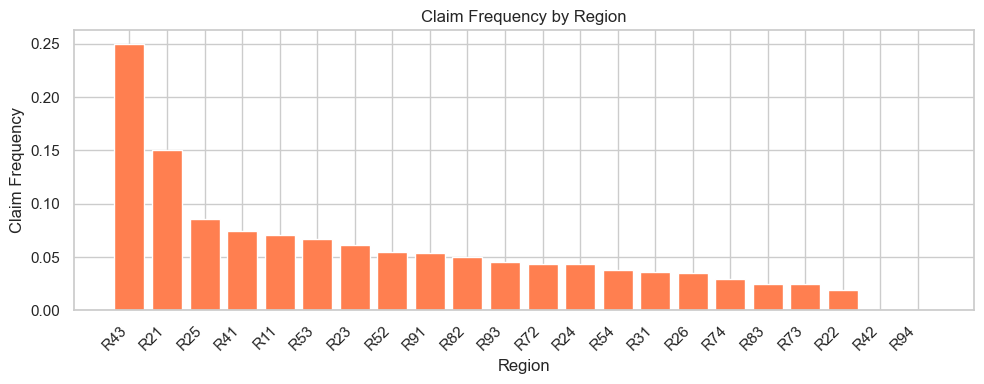

In [6]:
# Claim frequency by Region
freq_by_region = (
    df.groupby("Region")
    .agg(claim_freq=("ClaimNb", lambda x: (x.astype(float) > 0).mean()), n=("ClaimNb", "count"))
    .reset_index()
    .sort_values("claim_freq", ascending=False)
)
plt.figure(figsize=(10, 4))
plt.bar(freq_by_region["Region"].astype(str), freq_by_region["claim_freq"], color="coral")
plt.title("Claim Frequency by Region")
plt.xlabel("Region")
plt.ylabel("Claim Frequency")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../data/sample/eda_freq_by_region.png", dpi=80)
plt.show()


Policies with claims: 181


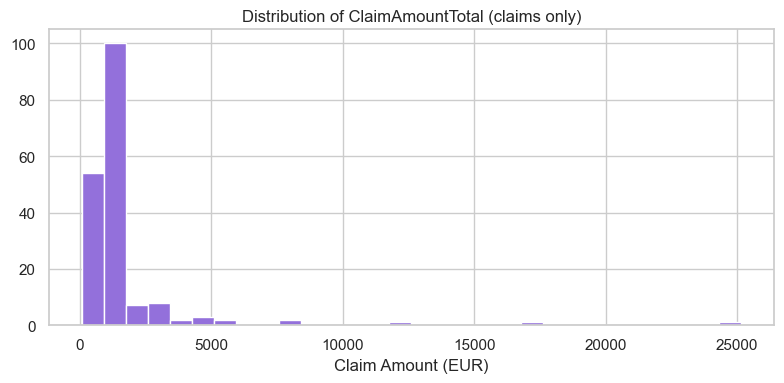

EDA complete.


In [7]:
# Claim amounts distribution (where > 0)
claim_df = df[df["ClaimAmountTotal"] > 0]
print(f"Policies with claims: {len(claim_df)}")
plt.figure(figsize=(8, 4))
plt.hist(claim_df["ClaimAmountTotal"], bins=30, color="mediumpurple", edgecolor="white")
plt.title("Distribution of ClaimAmountTotal (claims only)")
plt.xlabel("Claim Amount (EUR)")
plt.tight_layout()
plt.savefig("../data/sample/eda_claim_amount_dist.png", dpi=80)
plt.show()
print("EDA complete.")
